In [22]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np

In [3]:
kaggle_results_path = "/home/brend/projects/kaggle_runs/full_ind_vs_trans/"
kernel_types = ["2layer", "3layer", "conv1d", "conv2d", "dense_latency", "dense_resource", "exemplar", "rule4ml"]
models = {}
training_histories = {}

for kernel_type in kernel_types:
    models[kernel_type] = torch.load(f"{kaggle_results_path}/models/trans_vs_ind_test_{kernel_type}_model.pt")
    with open(f"{kaggle_results_path}/training_histories_{kernel_type}.json", "r") as f:
        training_histories[kernel_type] = json.load(f)


In [ ]:
for k, v in training_histories["2layer"].items():
    print(k)

train_loss
val_loss
r_per_target
std_ratio_per_target
best_val_preds
best_val_targets
y_means
y_stds
best_val_loss
best_epoch
test_loss
test_preds
test_targets


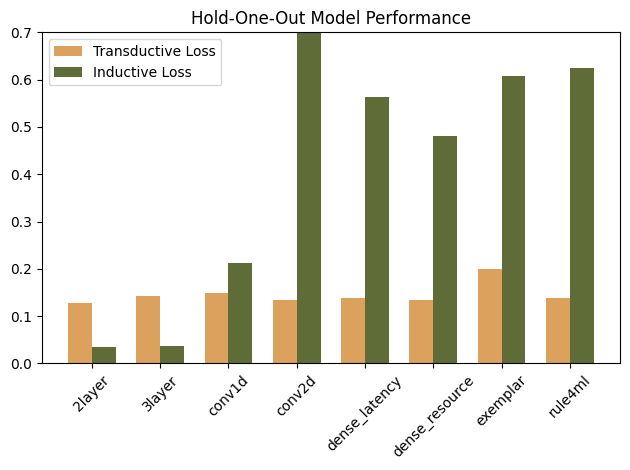

In [45]:
# Bar chart of best validation loss vs test loss for each kernel type
x = np.arange(len(kernel_types))
width = 0.35

plt.bar(
    x - width/2,
    [training_histories[k]["best_val_loss"] for k in kernel_types],
    width,
    label="Transductive Loss",
    color="#dda15e"
)

plt.bar(
    x + width/2,
    [training_histories[k]["test_loss"] for k in kernel_types],
    width,
    label="Inductive Loss",
    color="#606c38"
)

plt.xticks(x, kernel_types, rotation=45)
plt.ylim(0, 0.7)
plt.legend()
plt.title("Hold-One-Out Model Performance")
plt.tight_layout()
plt.show()


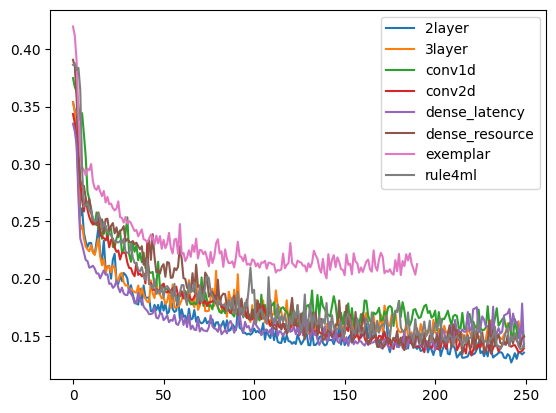

In [ ]:
# Plot validation losses for each kernel type on same graph
for kernel_type in kernel_types:
    plt.plot(training_histories[kernel_type]["val_loss"], label=kernel_type)
plt.legend()
plt.show()

In [58]:
print(training_histories["3layer"]["best_val_preds"])

[[-1.0557547807693481, -1.0481834411621094, -0.31068724393844604, -0.8412504196166992, -0.1800839751958847, -0.682656466960907, -0.5446428656578064], [-0.061533257365226746, -0.4481605887413025, -1.2233407497406006, -0.5356580018997192, -0.17099067568778992, -0.7987693548202515, -0.806471049785614], [-0.07594461739063263, -0.03813779354095459, 0.35960620641708374, -0.42551007866859436, -0.17968182265758514, -0.35379934310913086, -0.2770644426345825], [-0.6928279995918274, -0.8509450554847717, 0.2149743288755417, -0.15326395630836487, -0.1607864499092102, -0.6316993832588196, -0.7161350250244141], [0.7278043031692505, 0.6672210693359375, 0.5769320130348206, -0.30396074056625366, -0.15394890308380127, -0.14051638543605804, -0.11102232336997986], [0.6957589983940125, 0.604377269744873, 0.47232872247695923, -0.36346960067749023, -0.15966194868087769, -0.20635129511356354, -0.16471345722675323], [0.1470714509487152, -0.21805328130722046, -0.5045588612556458, 0.3320870101451874, -0.181346625

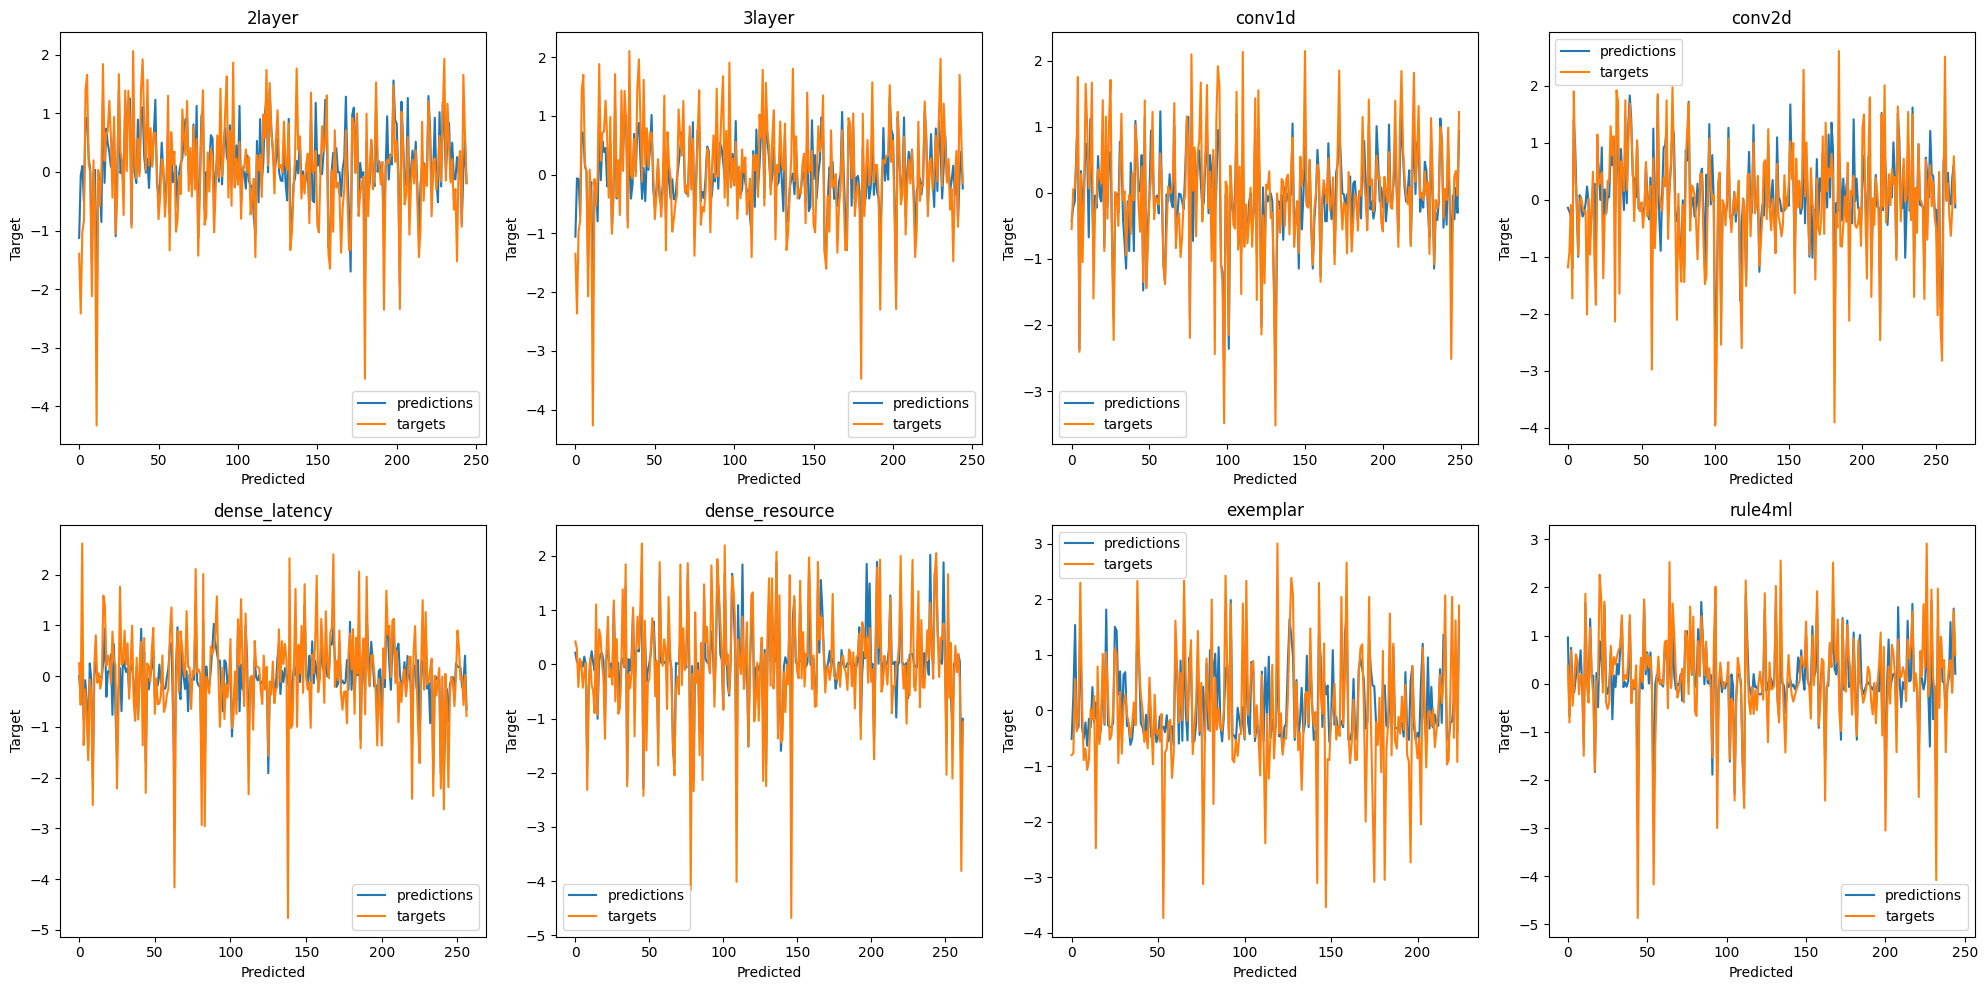

In [ ]:
# Plot validation preds vs targets for each kernel type on multi-figure
num_kernels = len(kernel_types)
num_rows = 2
num_cols = num_kernels // num_rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5))

for i, kernel_type in enumerate(kernel_types):
    preds = np.array(training_histories[kernel_type]["best_val_preds"])[:, 0]
    targets = np.array(training_histories[kernel_type]["best_val_targets"])[:, 0]
    sorted_idx = targets.argsort()
    ax = axes[i // num_cols, i % num_cols]
    ax.plot(preds, label="predictions")
    ax.plot(targets, label="targets")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Target")
    ax.set_title(kernel_type)
    ax.legend()
plt.tight_layout()
plt.show()